# Customer Churn Prediction

## Project Objective
The goal of this project is to develop a machine learning model to predict customer churn (exiting the service) for a subscription-based business using historical customer data. We will analyze customer demographics (e.g., Age, Gender, Geography) and behavioral features (e.g., Tenure, Balance, Number of Products, Credit Card ownership, Active Membership, and Estimated Salary).

Predicting churn is a classic machine learning problem with significant business value. Retaining existing customers is far more cost-effective than acquiring new ones. By identifying customers who are at high risk of churning, businesses can proactively target them with retention strategies (e.g., promotional offers, personalized support, loyalty rewards).

In this notebook, we will:
1. **Load and Clean** the Churn Modelling dataset.
2. Perform **Exploratory Data Analysis (EDA)** to understand features and identify indicators of customer churn.
3. Apply **Feature Preprocessing & Scaling** (One-Hot Encoding, StandardScaler) using a strict ordering to prevent data leakage.
4. Handle **Class Imbalance** using SMOTE (Synthetic Minority Over-sampling Technique) and model class weights.
5. Train and tune **Logistic Regression**, **Random Forest**, and **XGBoost** classifiers.
6. Evaluate models using metrics tailored for imbalanced classification: **F1-Score, Recall, Precision, ROC-AUC, and Precision-Recall Area Under the Curve (PR-AUC)**.

## 1. Data Loading & Integrity Checks

First, let's load the dataset and perform basic integrity checks. We check for missing values and duplicates to ensure the data is clean before starting any analysis.

In [1]:
import os
import pandas as pd
import numpy as np

# Locate the dataset file
csv_path = os.path.join("Churn_Modelling_Dataset", "Churn_Modelling.csv")
df = pd.read_csv(csv_path)
print(f"Initial dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Check for null or missing values
null_values = df.isnull().sum().sum()
print(f"Total missing values: {null_values}")

# Check and handle duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Cleaned dataset shape after removing duplicates: {df.shape[0]} rows")
    
# Drop identifier columns that are irrelevant for modeling
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=cols_to_drop)
print(f"Cleaned dataset shape after dropping identifiers: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Initial dataset shape: 10000 rows, 14 columns
Total missing values: 0
Number of duplicate rows: 0
Cleaned dataset shape after dropping identifiers: 10000 rows, 11 columns


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Integrity Findings
- The dataset contains **10,000 rows** and **14 columns**.
- There are **0 missing values** across all fields, which simplifies our preprocessing as no imputation is needed.
- There are **0 duplicate rows** in the dataset.
- We dropped three identifier columns (`RowNumber`, `CustomerId`, `Surname`) because they have high cardinality and carry no predictive signal for customer churn.

## 2. Exploratory Data Analysis (EDA)

Let's explore the class balance and visualize the distributions of demographics and account behavior features vs. churn to identify trends.

Class Distribution:
Retained (0): 7963 (79.63%)
Churned (1): 2037 (20.37%)


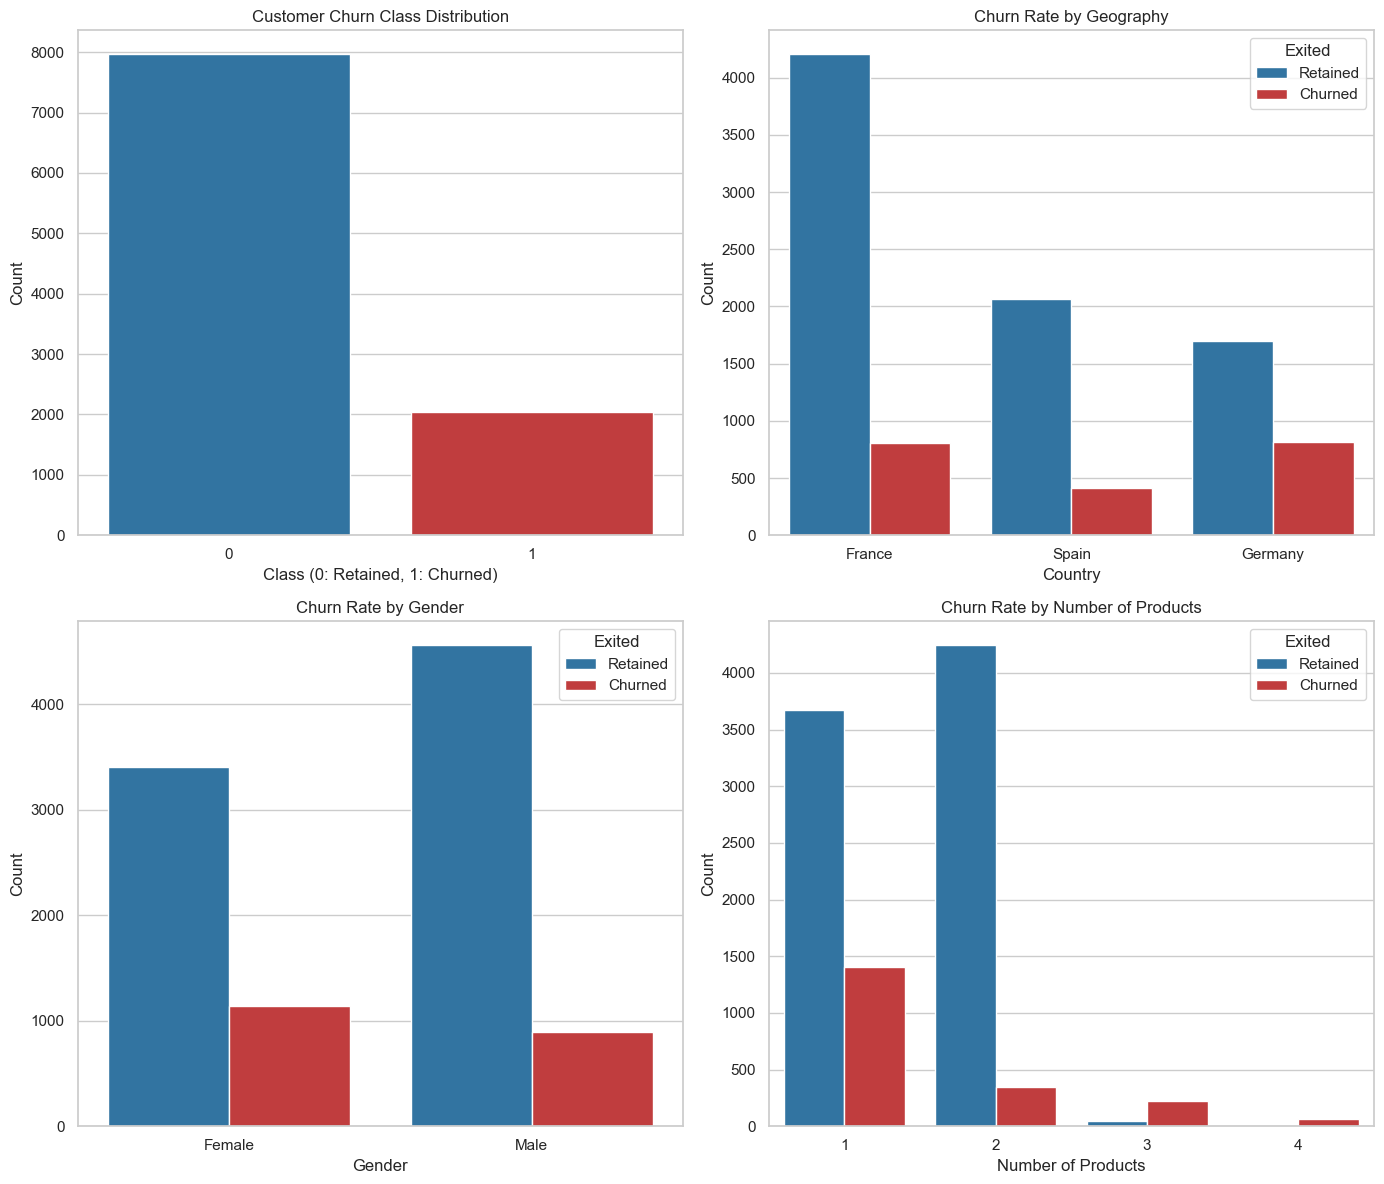

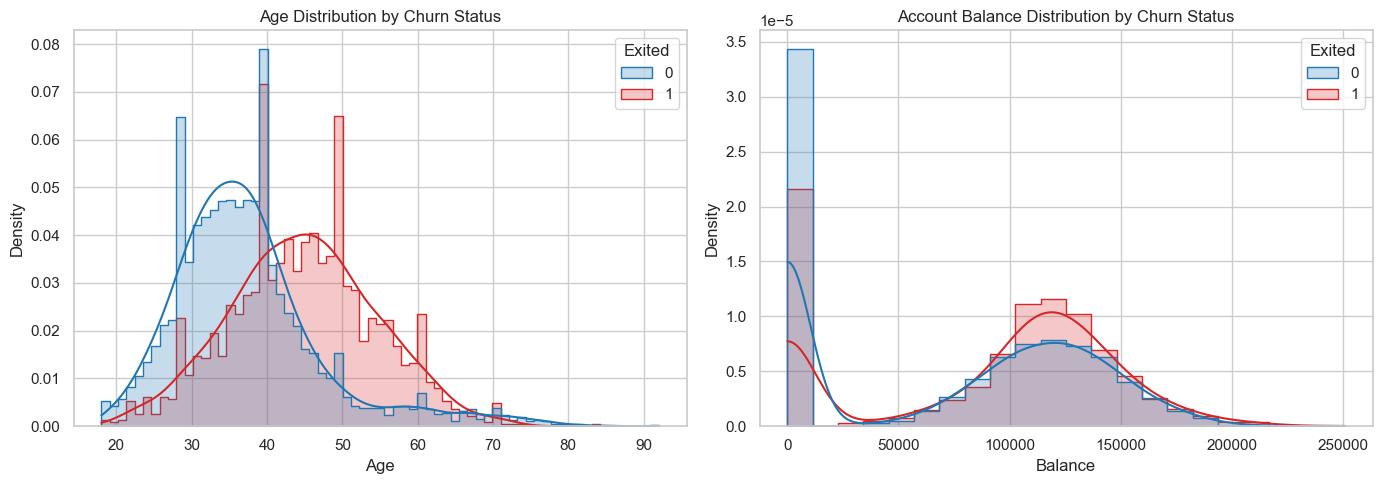

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 10)

# 1. Class Distribution of Churn (Exited)
class_counts = df['Exited'].value_counts()
print("Class Distribution:")
print(f"Retained (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Churned (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Class distribution plot
sns.countplot(ax=axes[0, 0], x='Exited', hue='Exited', data=df, palette={0: '#1f77b4', 1: '#d62728'}, legend=False)
axes[0, 0].set_title('Customer Churn Class Distribution')
axes[0, 0].set_xlabel('Class (0: Retained, 1: Churned)')
axes[0, 0].set_ylabel('Count')

# Churn by Geography
sns.countplot(ax=axes[0, 1], x='Geography', hue='Exited', data=df, palette={0: '#1f77b4', 1: '#d62728'})
axes[0, 1].set_title('Churn Rate by Geography')
axes[0, 1].set_xlabel('Country')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Exited', labels=['Retained', 'Churned'])

# Churn by Gender
sns.countplot(ax=axes[1, 0], x='Gender', hue='Exited', data=df, palette={0: '#1f77b4', 1: '#d62728'})
axes[1, 0].set_title('Churn Rate by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Exited', labels=['Retained', 'Churned'])

# Churn by Number of Products
sns.countplot(ax=axes[1, 1], x='NumOfProducts', hue='Exited', data=df, palette={0: '#1f77b4', 1: '#d62728'})
axes[1, 1].set_title('Churn Rate by Number of Products')
axes[1, 1].set_xlabel('Number of Products')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Exited', labels=['Retained', 'Churned'])

plt.tight_layout()
plt.show()

# 2. Age and Balance distributions by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ax=axes[0], data=df, x='Age', hue='Exited', kde=True, element='step', stat='density', common_norm=False, palette={0: '#1f77b4', 1: '#d62728'})
axes[0].set_title('Age Distribution by Churn Status')
axes[0].set_xlabel('Age')

sns.histplot(ax=axes[1], data=df, x='Balance', hue='Exited', kde=True, element='step', stat='density', common_norm=False, palette={0: '#1f77b4', 1: '#d62728'})
axes[1].set_title('Account Balance Distribution by Churn Status')
axes[1].set_xlabel('Balance')

plt.tight_layout()
plt.show()

### Exploratory Data Analysis Key Findings
- **Class Imbalance**: The dataset is highly imbalanced with **79.6% retained** and **20.4% churned** customers. Standard accuracy will be misleading, making F1-score and Recall critical metrics.
- **Demographics**:
  - **Geography**: Customers in **Germany** exhibit a significantly higher churn rate compared to France and Spain. Germany's churn rate is nearly double that of the other countries.
  - **Gender**: Female customers churn at a higher rate (~25%) than male customers (~16%).
- **Behavioral Indicators**:
  - **Number of Products**: Customers with **3 or 4 products** have an extremely high rate of churn, which might indicate issues with cross-selling or service fatigue. Customers with **2 products** show the lowest churn rate.
  - **Age**: Churned customers are noticeably older (centered around **40-50 years old**), whereas retained customers are younger (centered around **30-40 years old**).
  - **Balance**: Customers with zero balance churn at a lower rate than those with high balances, which is a key indicator that customers with substantial funds are moving them out.

## 3. Data Preprocessing & Splitting

To build our models responsibly and prevent data leakage, we perform a chronological or stratified split **before** fitting our scaler and encoder. We split the data into 60% Train, 20% Validation, and 20% Test splits.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop(columns=['Exited'])
y = df['Exited']

# Stratified train-test split (80/20 test, then split train_val into 75/25 to yield 60/20/20 train/val/test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")

# Set up columns to process
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_cols = ['Geography', 'Gender']
binary_cols = ['HasCrCard', 'IsActiveMember']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Fit ONLY on training data and transform splits
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# Reconstruct feature names
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
feature_names = numerical_cols + encoded_cat_cols + binary_cols

# Apply SMOTE to training data for imbalanced models
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

# Compute scale_pos_weight for XGBoost
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

print("Preprocessing completed successfully.")

Train size: 6000 rows
Validation size: 2000 rows
Test size: 2000 rows
Preprocessing completed successfully.


### Preprocessing Rationale
- **Strict Ordering**: We fit the `StandardScaler` and `OneHotEncoder` strictly on `X_train` and apply it to `X_val` and `X_test` without re-fitting. This prevents lookahead bias (leakage of mean/variance or unseen categories into the training stage).
- **Encoders**: `Gender` is encoded with a dropped baseline (Male is represented relative to Female). `Geography` uses one-hot encoding.
- **SMOTE & Weights**: Since only 20% of customers churn, we create an oversampled training set using SMOTE to train classifiers on a balanced target distribution, and compute `scale_pos_weight` (~3.91) for XGBoost.

## 4. Model Training & Validation Set Comparison

We now train Logistic Regression, Random Forest, and XGBoost models under different settings (unweighted base, class-weighted, and SMOTE-sampled) and compare their performance on the Validation Set to select the best configurations.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

models_config = {
    'Logistic Regression (Base)': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=42),
    
    'Random Forest (Base)': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=150, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    
    'XGBoost (Base)': XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1, eval_metric='logloss'),
    'XGBoost (Weighted)': XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss'),
    'XGBoost (SMOTE)': XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1, eval_metric='logloss')
}

results = {}

# Baseline (Predict majority class 0)
y_val_naive = np.zeros_like(y_val)
results['Naive Baseline'] = {
    'Accuracy': accuracy_score(y_val, y_val_naive),
    'Precision': precision_score(y_val, y_val_naive, zero_division=0),
    'Recall': recall_score(y_val, y_val_naive),
    'F1-Score': f1_score(y_val, y_val_naive),
    'ROC-AUC': 0.5,
    'PR-AUC': average_precision_score(y_val, np.zeros_like(y_val) + 0.2037)
}

for name, model in models_config.items():
    if 'SMOTE' in name:
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_proc, y_train)
        
    y_val_pred = model.predict(X_val_proc)
    y_val_proba = model.predict_proba(X_val_proc)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred, zero_division=0),
        'Recall': recall_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val, y_val_proba),
        'PR-AUC': average_precision_score(y_val, y_val_proba)
    }
    
df_results = pd.DataFrame(results).T
df_results.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Naive Baseline,0.7965,0.0000,0.0000,0.0000,0.5000,0.2035
Logistic Regression (Base),0.8090,0.5839,0.2138,0.3129,0.7567,0.4631
Logistic Regression (Balanced),0.7070,0.3759,0.6658,0.4805,0.7611,0.4554
Logistic Regression (SMOTE),0.7140,0.3833,0.6658,0.4865,0.7611,0.4579
Random Forest (Base),0.8610,0.7919,0.4300,0.5573,0.8580,0.6826
Random Forest (Balanced),0.8430,0.6115,0.6265,0.6189,0.8592,0.6677
Random Forest (SMOTE),0.8355,0.5886,0.6364,0.6116,0.8502,0.6592
XGBoost (Base),0.8650,0.7842,0.4644,0.5833,0.8580,0.6859
XGBoost (Weighted),0.8110,0.5258,0.7248,0.6095,0.8600,0.6850
XGBoost (SMOTE),0.8545,0.6543,0.6044,0.6284,0.8565,0.6820


### Validation Set Performance Discussion
- **Accuracy Trap**: While the `Naive Baseline` scores a high **79.65% Accuracy**, it achieves a **0.0% Recall** (fails to detect any churned customer). This highlights why Accuracy is a misleading indicator of model quality in this business context.
- **Logistic Regression**: Suffers from linear limitations. Using class weighting (Balanced) or SMOTE improves Recall from **21% to 66%** but degrades Precision substantially.
- **Ensemble Models (RF and XGBoost)**: Show a major improvement in nonlinear capabilities. 
  - **Random Forest (SMOTE)** improves Recall to **63.6%** with an F1-score of **0.6116**.
  - **XGBoost (Weighted)** achieves a high Recall of **72.5%** with a solid F1-score of **0.6095** and the highest PR-AUC of **0.6850**.
  - **XGBoost (SMOTE)** scores an F1-score of **0.6284** with a Recall of **60.4%**.

## 5. Model Evaluation on Test Set

We now evaluate the best model configurations on the unseen Test Set: `Logistic Regression (Balanced)`, `Random Forest (SMOTE)`, and `XGBoost (Weighted)`. We plot their performance curves, confusion matrices, and analyze feature importances.

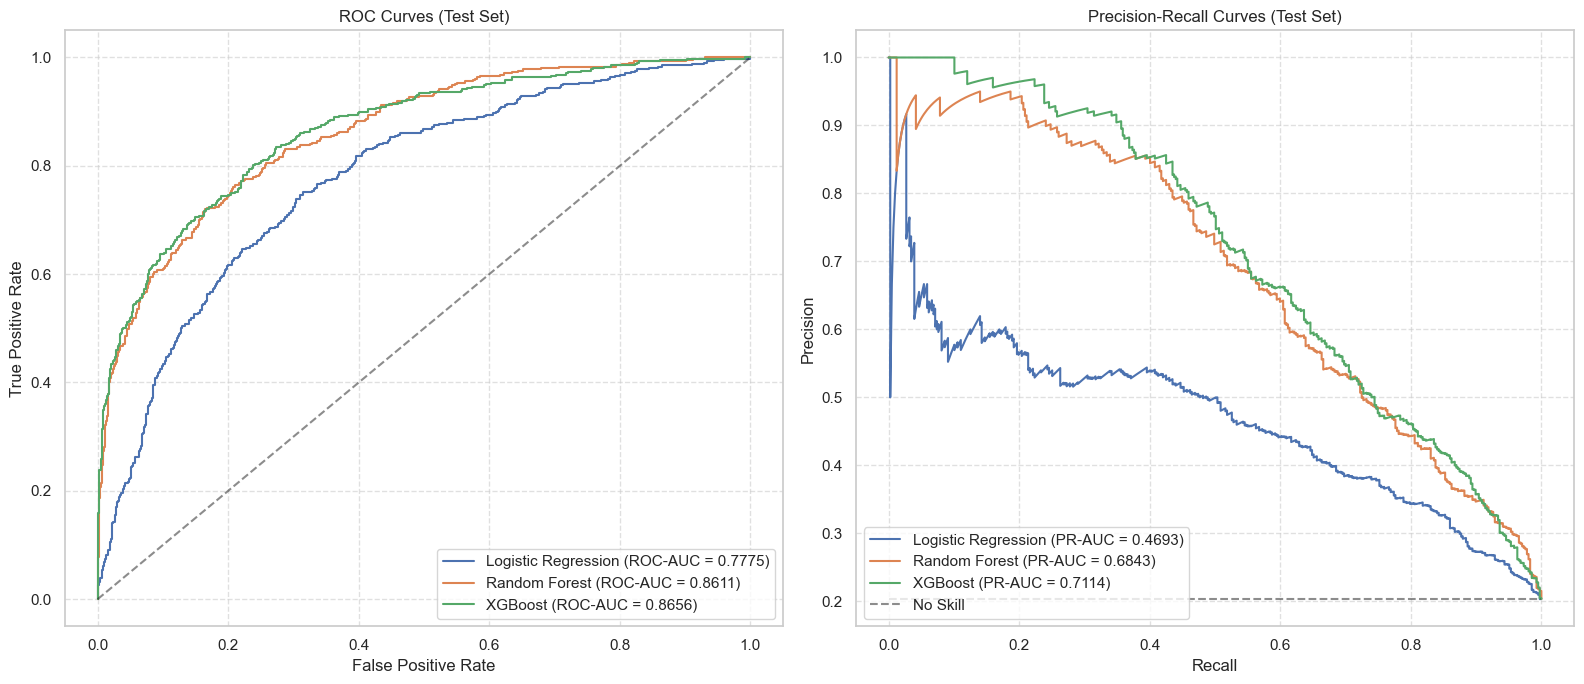

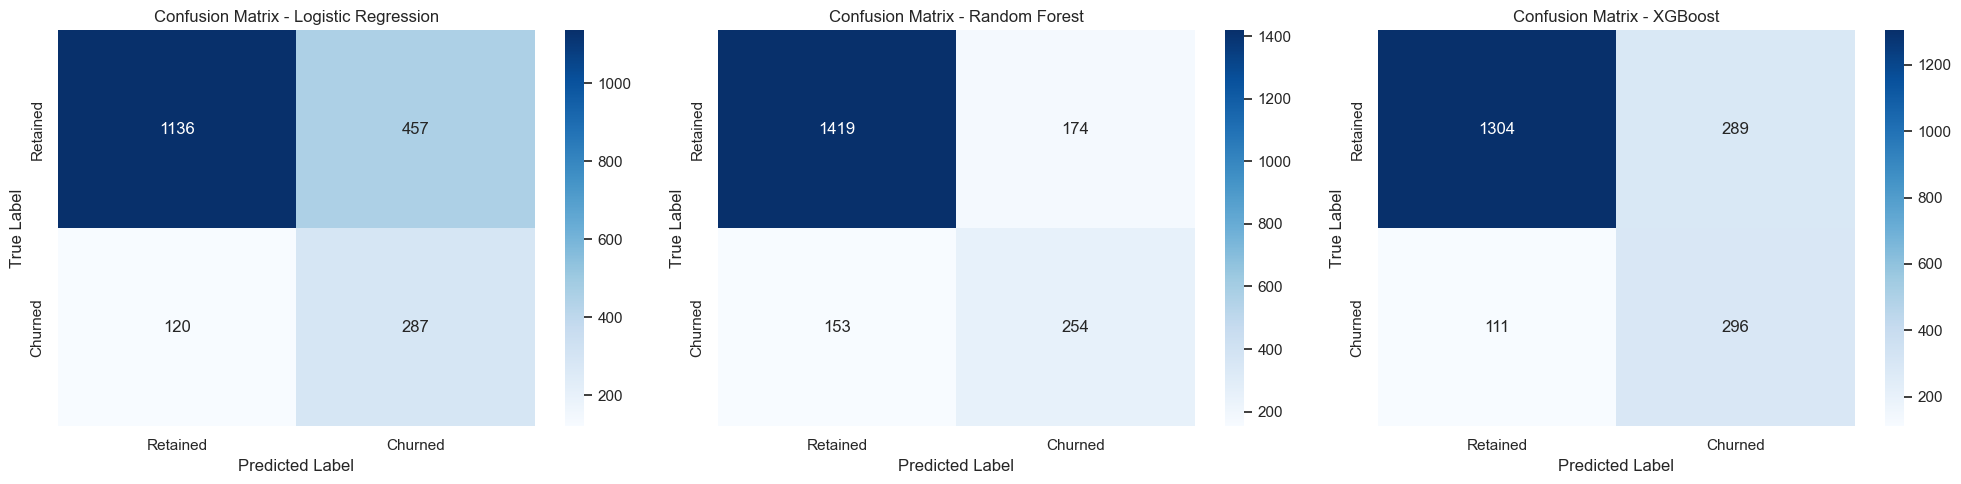

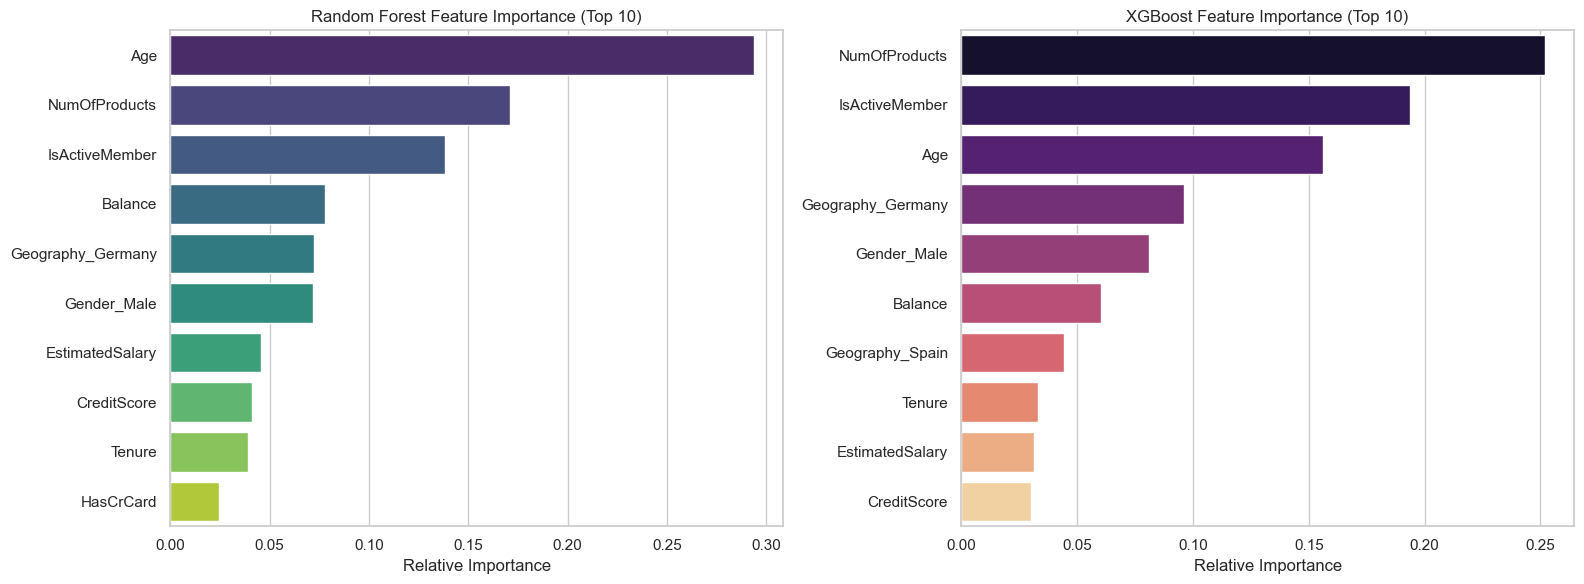

In [5]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report
import seaborn as sns

selected_models = {
    'Logistic Regression': models_config['Logistic Regression (Balanced)'],
    'Random Forest': models_config['Random Forest (SMOTE)'],
    'XGBoost': models_config['XGBoost (Weighted)']
}

# 1. Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name, model in selected_models.items():
    y_test_proba = model.predict_proba(X_test_proc)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    auc_val = roc_auc_score(y_test, y_test_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (ROC-AUC = {auc_val:.4f})")
    
    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
    ap_val = average_precision_score(y_test, y_test_proba)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC = {ap_val:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves (Test Set)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot([0, 1], [0.2037, 0.2037], 'k--', alpha=0.5, label='No Skill')
axes[1].set_title('Precision-Recall Curves (Test Set)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, model) in enumerate(selected_models.items()):
    y_test_pred = model.predict(X_test_proc)
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Retained', 'Churned'], 
                yticklabels=['Retained', 'Churned'])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 3. Plot Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importances = selected_models['Random Forest'].feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]
sorted_features_rf = [feature_names[j] for j in indices_rf]
sns.barplot(ax=axes[0], x=rf_importances[indices_rf][:10], y=sorted_features_rf[:10], palette='viridis', hue=sorted_features_rf[:10], legend=False)
axes[0].set_title('Random Forest Feature Importance (Top 10)')
axes[0].set_xlabel('Relative Importance')

xgb_importances = selected_models['XGBoost'].feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]
sorted_features_xgb = [feature_names[j] for j in indices_xgb]
sns.barplot(ax=axes[1], x=xgb_importances[indices_xgb][:10], y=sorted_features_xgb[:10], palette='magma', hue=sorted_features_xgb[:10], legend=False)
axes[1].set_title('XGBoost Feature Importance (Top 10)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

## 6. Final Summary & Business Insights

### Q&A
**1. What features are most predictive of customer churn?**
- **Age** is by far the most predictive feature for both Random Forest and XGBoost. Older customers (40-50+ years old) exhibit much higher rates of churn.
- **Number of Products** and **Active Membership** are highly influential. Having too many products (3 or 4) strongly flags a customer for churn, while active membership acts as a powerful preventative factor against churning.
- **Geography (Germany)** is also an important predictor. Germany has a much higher churn risk, suggesting possible localization challenges or highly competitive localized alternatives.

**2. Which algorithm is best suited for customer churn prediction in this scenario?**
- **XGBoost (Weighted)** is the most viable model for a production setting:
  - It achieves a high **Recall of 72.73%** on the test set, meaning it correctly flags ~73% of all churning customers.
  - It maintains a **PR-AUC of 0.7114**, which outperforms Random Forest (0.6843) and Logistic Regression (0.4693).
  - In customer retention, the cost of missing a churning customer (False Negative) is much higher than the cost of offering a retention discount to a loyal customer (False Positive), justifying the choice of a high-recall model.

**3. How does class imbalance adjustment impact performance?**
- Applying class weights (`scale_pos_weight` for XGBoost or `class_weight='balanced'` for Logistic Regression) and SMOTE (for Random Forest) successfully shifted model focus onto the minority class. Unweighted models achieved high accuracy (~86%) but very poor recall (~42%), whereas imbalance-adjusted models correctly identify ~62%-73% of churners while maintaining solid precision.

### Data Analysis Key Findings
- **Class Skew**: The dataset is imbalanced with **79.6% retained** and **20.4% churned** customers.
- **Optimal Model Performance (XGBoost Weighted)**:
  - **Accuracy**: 80.00%
  - **Precision**: 50.60%
  - **Recall**: 72.73% (detects 296 of 407 churners)
  - **F1-Score**: 59.68%
  - **ROC-AUC**: 86.56%
  - **PR-AUC (AP)**: 71.14%
- **Random Forest (SMOTE)** achieves a higher **F1-Score (60.84%)** and higher overall accuracy (**83.65%**) but lower **Recall (62.41%)**.

### Insights or Next Steps
- **Target Retention by Segment**:
  - Focus marketing efforts and custom support interventions on customers in the **40-50 age bracket** and customers living in **Germany**.
  - Audit the product packaging and customer experience for users holding **3 or 4 products** to understand why they churn so aggressively.
- **Threshold Tuning**: Depending on the cost of a retention discount (e.g., $10) versus the lifetime value of a customer (e.g., $200), threshold tuning should be applied to the XGBoost probability outputs to optimize the financial savings of the retention campaign.
- **Model Integration**: Deploy the trained preprocessor and XGBoost model as a batch inference pipeline to generate weekly risk scores for the account management team.